# Hyperparameter Tuning with Optuna — Fashion-MNIST ANN

## Overview

A neural network has two kinds of "knobs":

- **Parameters** — the weights the network *learns* from data during training.
- **Hyperparameters** — settings *we* choose *before* training: number of layers, layer width, optimizer, learning rate, dropout, and so on.

The network can't learn its own hyperparameters, and a strong architecture with a bad learning rate loses to a simple one that's well tuned. **Optuna** searches for good hyperparameters automatically: we define a search space and a score to maximise (here, test accuracy), and it proposes combinations, learns from the results, and homes in on the best — more efficiently than grid or random search.

**Goal:** build an ANN that classifies 28×28 grayscale clothing images into 10 classes, with its hyperparameters tuned by Optuna.

| Step | What happens |
|------|--------------|
| 1 | Imports, reproducibility, device (CPU/GPU) setup |
| 2 | Load and visualise the Fashion-MNIST data |
| 3 | Preprocess: split, scale, wrap in a `Dataset` |
| 4 | Define a **parameterized** network |
| 5 | Write the Optuna **objective** function (the core idea) |
| 6 | Create a **study** and run the search |
| 7 | Read off the best score and hyperparameters |

Run the cells top-to-bottom. Step 5 is the heart of the lab.

## Step 1 — Imports, reproducibility & device

Import PyTorch (model + training), pandas / scikit-learn (data), and matplotlib (plots). We fix random seeds so runs are repeatable, and detect a GPU (training uses it automatically if present).

**Note:** on Colab, enable a GPU via *Runtime → Change runtime type → GPU* — the device line will then print `cuda` and training will be much faster.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds so every run is reproducible.
# Optuna still explores different hyperparameters each trial, but the randomness
# *inside* training (weight initialisation, batch shuffling) stays fixed.
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 2 — Load and explore the data

**Fashion-MNIST**: 70,000 grayscale images (28×28) of clothing in 10 classes. In CSV form, each row is one image — column 0 is the **label** (0–9), the next **784 columns** are pixel values (0–255).

**Getting the data** (`fashion-mnist_train.csv`): on Colab, upload it (it lands in `/content/`); locally, put it beside this notebook or in a `data/` folder. The next cell checks all of these automatically. Source: Kaggle ("Fashion MNIST" by *zalando-research*).

In [ ]:
import kagglehub, os
import pandas as pd

path = kagglehub.dataset_download("zalando-research/fashionmnist")
df = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))
df.head()


Using Colab cache for faster access to the 'fashionmnist' dataset.


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

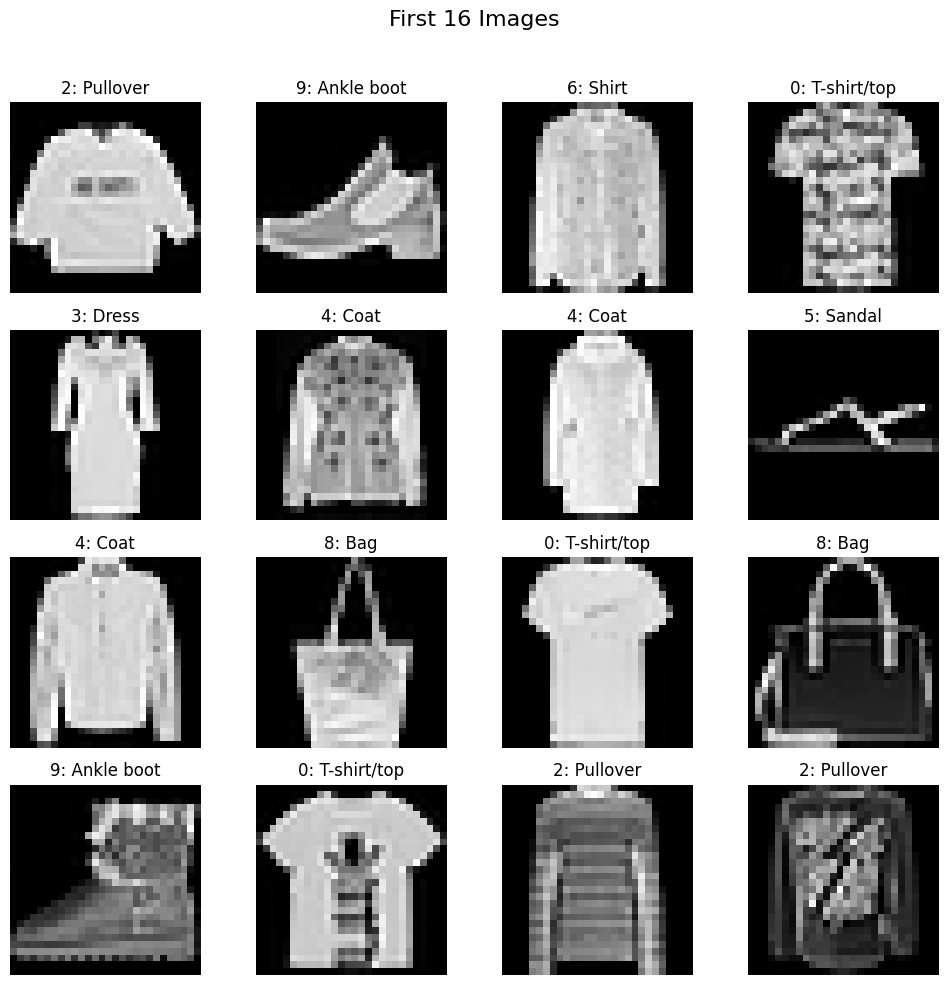

In [ ]:
# Fashion-MNIST labels are 0-9; here are the human-readable class names.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape flat 784 vector to 28x28
    ax.imshow(img, cmap='gray')                  # cmap='gray' shows true grayscale
    ax.axis('off')                               # Remove axis for a cleaner look
    label = df.iloc[i, 0]
    ax.set_title(f"{label}: {class_names[label]}")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

## Step 3 — Preprocess the data

Three steps turn the raw table into training-ready data:

1. **Split features / labels** — column 0 is `y`; columns 1–784 are the pixels `X`.
2. **Train / test split** — 80% to train, 20% held out for honest evaluation.
3. **Scale to [0, 1]** — dividing by 255 keeps inputs small and stable, which helps optimisation.

**Hint:** scaling *after* the split is the safe habit — it stops test-set information from leaking into training.

In [ ]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

### Wrapping the data in a PyTorch `Dataset`

A `DataLoader` feeds the model mini-batches, and it needs a `Dataset` that knows **how many** samples exist (`__len__`) and **how to fetch one** (`__getitem__`). `CustomDataset` also converts arrays to tensors — `float32` for pixels, `long` for the integer labels `CrossEntropyLoss` expects.

**Note:** the `DataLoader` is created later, *inside* the objective function — because `batch_size` is a hyperparameter Optuna will tune.

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)

In [ ]:
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
# Sanity check: how many samples ended up in each split?
len(train_dataset), len(test_dataset)

(48000, 12000)

## Step 4 — A parameterized network

Rather than hard-coding one architecture, `MyNN` is built from its constructor arguments: `num_hidden_layers` (depth), `neurons_per_layer` (width), and `dropout_rate` (regularisation). Each hidden block is `Linear → BatchNorm → ReLU → Dropout`, repeated, then a final `Linear` producing 10 class scores.

Because the shape is driven by arguments, **Optuna can reshape the whole network just by changing numbers.**

In [ ]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

## Step 5 — The Optuna objective function (the core idea)

Optuna calls this once per **trial**: given a set of hyperparameters, build the model, train it, and return the score to maximise (test accuracy). For each hyperparameter we call `trial.suggest_*`; Optuna picks the next value based on what it learned from previous trials.

| Hyperparameter | Optuna call | Range / choices |
|---|---|---|
| Hidden layers | `suggest_int` | 1 – 5 |
| Neurons / layer | `suggest_int(step=8)` | 8 – 128 |
| Epochs | `suggest_int(step=10)` | 10 – 50 |
| Learning rate | `suggest_float(log=True)` | 1e-5 – 1e-1 |
| Dropout | `suggest_float(step=0.1)` | 0.1 – 0.5 |
| Batch size | `suggest_categorical` | 16, 32, 64, 128 |
| Optimizer | `suggest_categorical` | Adam, SGD, RMSprop |
| Weight decay | `suggest_float(log=True)` | 1e-5 – 1e-3 |

**Why `log=True`?** Learning rate and weight decay span orders of magnitude — `0.001` vs `0.01` matters more than `0.05` vs `0.06` — so log-scale sampling spends the budget where it counts.


The rest is a standard PyTorch loop (forward → loss → backprop → step), then accuracy on the test set under `eval()` mode.

In [ ]:
# objective function: Optuna calls this once per trial.
# It receives a `trial`, suggests hyperparameters from it, trains a model,
# and returns the score to maximise (test accuracy).
def objective(trial):

  # Ask the trial to suggest a value for each hyperparameter (the search space).
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  # DataLoaders are built here (not earlier) because batch_size is tuned.
  # pin_memory only helps when copying to a CUDA GPU, so enable it conditionally.
  pin = (device.type == 'cuda')
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # loss + optimizer selection
  # Each branch ASSIGNS `optimizer = ...` so the suggested optimizer,
  # learning_rate and weight_decay are actually used during training.

  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop
  model.train()
  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to the selected device (CPU/GPU)
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # backward pass
      optimizer.zero_grad()
      loss.backward()

      # update weights
      optimizer.step()

  # evaluation on the held-out test set
  model.eval()
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct / total

  # Optuna will try to maximise this returned value.
  return accuracy

## Step 6 — Create a study and run the search

A **study** manages the optimisation. We set `direction='maximize'` (higher accuracy is better; for a loss you'd use `'minimize'`). `study.optimize(objective, n_trials=10)` runs the objective 10 times with hyperparameters chosen by Optuna's default **TPE** sampler, which focuses future trials on promising regions.

**Runtime:** each trial trains a full network (up to 50 epochs), so this can be slow on CPU. If needed, lower `n_trials`, shrink the `epochs` range, or use a GPU.

In [ ]:
# Install Optuna if it isn't already available.
# (Colab usually needs this; skip it if Optuna is already installed locally.)
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.1 MB/s eta 0:00:00


In [ ]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2026-07-29 06:48:20,673] A new study created in memory with name: no-name-2e993dd2-37a9-42b7-83ad-102d7e83a88c


In [ ]:
study.optimize(objective, n_trials=10)

[I 2026-07-29 06:51:08,242] Trial 0 finished with value: 0.8580833333333333 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 80, 'epochs': 50, 'learning_rate': 0.004250325909035354, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.00011773103175938672}. Best is trial 0 with value: 0.8580833333333333.
[I 2026-07-29 06:51:53,632] Trial 1 finished with value: 0.8440833333333333 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 64, 'epochs': 10, 'learning_rate': 0.012691836149200518, 'dropout_rate': 0.30000000000000004, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.617685031925518e-05}. Best is trial 0 with value: 0.8580833333333333.
[I 2026-07-29 06:55:52,250] Trial 2 finished with value: 0.771 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 32, 'epochs': 40, 'learning_rate': 0.000819688872199516, 'dropout_rate': 0.4, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 2.8389686896523844e-05}. Best is tri

## Step 7 — Inspect the results

The study remembers its best trial: `study.best_value` (highest test accuracy) and `study.best_params` (the winning combination). These `best_params` are what you'd use to train a final model before deployment.

In [ ]:
study.best_value

0.8950833333333333

In [ ]:
study.best_params

{'num_hidden_layers': 5,
 'neurons_per_layer': 112,
 'epochs': 40,
 'learning_rate': 0.0001508200228908767,
 'dropout_rate': 0.1,
 'batch_size': 32,
 'optimizer': 'Adam',
 'weight_decay': 0.0008096555030391785}

## Key takeaways

- **Hyperparameters are searched, not learned** — Optuna does this in a few lines.
- **The objective function is the contract:** take a `trial`, train a model, return a score. Everything else is ordinary PyTorch.
- **`trial.suggest_*` defines the search space**, and the TPE sampler beats grid/random for the same budget.


**Next:** raise `n_trials`; visualise with `plot_optimization_history` / `plot_param_importances`; add a `MedianPruner`; or retrain a model on `study.best_params`.